In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import uproot
import awkward as ak
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys

In [2]:
file10 = uproot.open("AODSkimmer/corrected_signal_2022_files/HighEvents/final/Signal_Mchi-10p5_dMchi-1p0_ctau-10_output.root")
dir10= file10["ntuples"]    
tree10 = dir10["outT"]

file100 = uproot.open("AODSkimmer/corrected_signal_2022_files/HighEvents/final/Signal_Mchi-31p5_dMchi-3p0_ctau-10_output.root")
dir100= file100["ntuples"]    
tree100 = dir100["outT"]

file1000 = uproot.open("AODSkimmer/corrected_signal_2022_files/HighEvents/final/Signal_Mchi-52p5_dMchi-5p0_ctau-10_output.root")
dir1000= file1000["ntuples"]    
tree1000 = dir1000["outT"]

In [3]:
pdgs10 = tree10["GenPart_ID"].array()
mask10 = pdgs10==1000023

pdgs100 = tree100["GenPart_ID"].array()
mask100 = pdgs100==1000023

pdgs1000 = tree1000["GenPart_ID"].array()
mask1000 = pdgs1000==1000023

In [4]:
energy10 = tree10["GenPart_e"].array()
energychi210=energy10[mask10]

mass10 = tree10["GenPart_mass"].array()
mchi210 = mass10[mask10]
gamma10= energychi210/mchi210

energy100 = tree100["GenPart_e"].array()
energychi2100=energy100[mask100]

mass100 = tree100["GenPart_mass"].array()
mchi2100 = mass100[mask100]
gamma100= energychi2100/mchi2100

energy1000 = tree1000["GenPart_e"].array()
energychi21000=energy1000[mask1000]

mass1000 = tree1000["GenPart_mass"].array()
mchi21000 = mass1000[mask1000]
gamma1000= energychi21000/mchi21000



In [5]:
vx_chi2 = ak.flatten(tree10['GenPart_vx'].array()[mask10])
vy_chi2 = ak.flatten(tree10['GenPart_vy'].array()[mask10])
vz_chi2 = ak.flatten(tree10['GenPart_vz'].array()[mask10])

vx_chi200 = ak.flatten(tree100['GenPart_vx'].array()[mask100])
vy_chi200 = ak.flatten(tree100['GenPart_vy'].array()[mask100])
vz_chi200 = ak.flatten(tree100['GenPart_vz'].array()[mask100])


vx_chi2000 = ak.flatten(tree1000['GenPart_vx'].array()[mask1000])
vy_chi2000 = ak.flatten(tree1000['GenPart_vy'].array()[mask1000])
vz_chi2000 = ak.flatten(tree1000['GenPart_vz'].array()[mask1000])


# plt.hist(vx_chi2,histtype="step",color = 'black', linewidth=1.5, label="Chi2_vx")
# plt.hist(vy_chi2,histtype="step",color = 'red', linewidth=1.5, label="Chi2_vy")
# #plt.hist(vz_chi2,histtype="step",color = 'blue', linewidth=1.5, label="GenPart_vz")

# plt.xlabel("Vertex position [cm]")
# plt.legend()
# plt.title("Gen level vertex position for Chi2 in transverse plane")
# plt.show()

Text(0.5, 0, 'Chi2_vz')

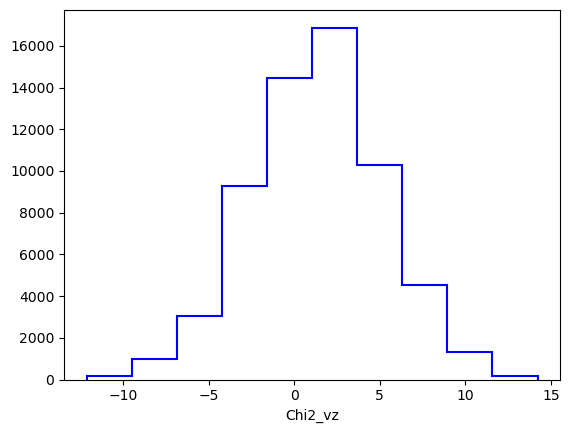

In [6]:
plt.hist(vz_chi2,histtype="step",color = 'blue', linewidth=1.5)
plt.xlabel("Chi2_vz")

In [7]:
vx_genele = tree10['GenEle_vx'].array() 
vy_genele = tree10['GenEle_vy'].array() 
vz_genele = tree10['GenEle_vz'].array() 


vx_genele100 = tree100['GenEle_vx'].array() 
vy_genele100 = tree100['GenEle_vy'].array() 
vz_genele100 = tree100['GenEle_vz'].array() 

vx_genele1000 = tree1000['GenEle_vx'].array() 
vy_genele1000 = tree1000['GenEle_vy'].array() 
vz_genele1000 = tree1000['GenEle_vz'].array() 

# plt.hist(vx_genele,histtype="step",color = 'blue', bins=20, linewidth=1.5, label="GenEle_vx")
# plt.hist(vy_genele,histtype="step",color = 'black', bins=20, linewidth=1.5, label="GenEle_vy")

# plt.xlabel("Vertex Position (in cm)")
# plt.title("Gen level vertex position for e- in transverse plane")
# plt.legend()
# plt.show()

In [8]:
decaylength_chi2 = np.sqrt( (vx_genele-vx_chi2)**2 + (vy_genele-vy_chi2)**2 + (vz_genele-vz_chi2)**2 )  #in cm
decaylength_chi200 = np.sqrt( (vx_genele100-vx_chi200)**2 + (vy_genele100-vy_chi200)**2 + (vz_genele100-vz_chi200)**2 )  #in cm
decaylength_chi2000 = np.sqrt( (vx_genele1000-vx_chi2000)**2 + (vy_genele1000-vy_chi2000)**2 + (vz_genele1000-vz_chi2000)**2 )  #in cm


In [9]:
ctau=decaylength_chi2/gamma10
ctau100=decaylength_chi200/gamma100
ctau1000=decaylength_chi2000/gamma1000

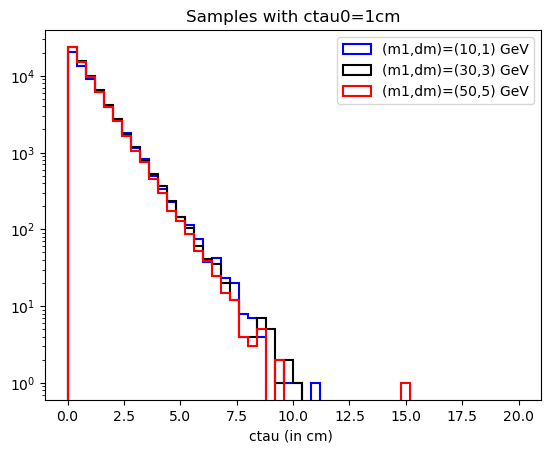

In [14]:
plt.hist(ctau,histtype="step",color = 'blue',linewidth=1.5, range=(0,20),bins=50, log=True, label="(m1,dm)=(10,1) GeV")
plt.hist(ctau100,histtype="step",color = 'black',linewidth=1.5, range=(0,20),bins=50, log=True, label="(m1,dm)=(30,3) GeV")
plt.hist(ctau1000,histtype="step",color = 'red',linewidth=1.5, range=(0,20),bins=50, log=True, label="(m1,dm)=(50,5) GeV")


plt.xlabel("ctau (in cm) ")
plt.legend()
plt.title("Samples with ctau0=1cm")
plt.savefig("ctau101001000", dpi=300)